# Importing Header and SoilPrep

In [1]:
import import_ipynb 
from Header import *

importing Jupyter notebook from Header.ipynb


C:\Users\abhis\AppData\Local\Programs\Python\Python311\Lib\site-packages\nbformat\__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)


In [2]:
import import_ipynb
from SoilPrep import * 

importing Jupyter notebook from SoilPrep.ipynb


C:\Users\abhis\AppData\Local\Programs\Python\Python311\Lib\site-packages\nbformat\__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)


# Step 0: Setting up decision parameters (Data Tree)

In [3]:
# 0. Available smoothing filter types: savgol1 and savgol2 ------------------------ (0)
sg_filters = ['sg2']

# 0. Available window lengths for the smoothing filter ---------------------------- (0)
window_lengths = [0, 1, 11, 21, 31, 41, 51, 71, 91]

# 1. Available machine learning regression models --------------------------------- (1)
ml_methods = ['ridge', 'svr', 'plsr', 'cubist', 'gbrt']

# 2. Names of target variables in the dataframe ----------------------------------- (2)
target_names = ['TOC']

# 3. Available preprocessing for Target data -------------------------------------- (3)
prepare_target = ['none']
# 4. Available preprocessing for Spectral data ------------------------------------ (4)
prepare_spec = ['none', 'cr', 'log', 'fod', 'fod_cr', 'fod_log']

# 5. Resampling bands available for spectra --------------------------------------- (5) 
nbands_sampling = [5,10,15,20,25,30,35, 40, 45, 50, 60, 70, 80, 90, 100]


# Setting colours for different targets        --------------------------------------
clr = ['green']

# Colour scheme definition
# kado = '#8B7355'
# mati = '#A52A2A'
# balu = '#F4A460'

In [4]:
MetaData = {'sg_filters' : sg_filters, 'window_lengths' : window_lengths, 'prepare_spec' : prepare_spec, \
            'nbands_sampling' : nbands_sampling, 'target_names' : target_names, 'prepare_target' : prepare_target,\
            'ml_methods' : ml_methods, 'clr' : clr}

with open ('meta_data.pickle', 'wb') as file:
    pickle.dump(MetaData, file)

# Step 1a: Obtaining Spectra (Noise and Outliers removal)

In [5]:
df = pd.read_csv('Italy.csv')
df.rename(columns = {'OC%': 'TOC'}, inplace = True)
df.head(1)

,TLV_idx,IT_idx,TAG_IT,XmUTM33,YmUTM33,soil depth (cm),average soil depth (cm),Texture class,Sand%,Silt%,Clay%,BD g/cm3,pH,CaCO3%,TOC,Carbon stock,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,370,371,372,373,374,375,376,377,378,379,380,381,382,383,...,2451,2452,2453,2454,2455,2456,2457,2458,2459,2460,2461,2462,2463,2464,2465,2466,2467,2468,2469,2470,2471,2472,2473,2474,2475,2476,2477,2478,2479,2480,2481,2482,2483,2484,2485,2486,2487,2488,2489,2490,2491,2492,2493,2494,2495,2496,2497,2498,2499,2500
0,1,126629.0,C2_4664,502765.35,4488814.14,0-7,3.5,sandy loam,47.75,27.62,24.63,1.506327,6.3,5.863,1.4,0.007381,0.074932,0.07695,0.069572,0.074459,0.084597,0.082278,0.084486,0.084062,0.078833,0.064853,0.065676,0.08092,0.078477,0.074822,0.073595,0.079095,0.073128,0.067866,0.073805,0.075564,0.077744,0.079301,0.076749,0.075715,0.078941,0.080916,0.076129,0.07307,0.077287,0.08146,0.081923,0.080122,0.079522,0.078779,...,0.389512,0.389017,0.388596,0.388203,0.387496,0.386679,0.385995,0.385343,0.384979,0.384798,0.384509,0.383982,0.383455,0.382667,0.381661,0.381222,0.380977,0.380462,0.38002,0.379234,0.377965,0.377186,0.376435,0.376151,0.37586,0.375003,0.374733,0.374094,0.373085,0.372541,0.371912,0.371266,0.370933,0.370718,0.370055,0.368958,0.368165,0.367614,0.367514,0.367988,0.368236,0.368705,0.368515,0.367891,0.367332,0.365998,0.365176,0.364963,0.365163,0.36501


In [6]:
temp_spec = df.iloc[:, 16::].copy()
spectra_df = temp_spec.iloc[:,50::].copy()
target_df = df.loc[:, [target_names[0]]].copy()

In [7]:
spectra_df.head(2)

,400,401,402,403,404,405,406,407,408,409,410,411,412,413,414,415,416,417,418,419,420,421,422,423,424,425,426,427,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447,448,449,...,2451,2452,2453,2454,2455,2456,2457,2458,2459,2460,2461,2462,2463,2464,2465,2466,2467,2468,2469,2470,2471,2472,2473,2474,2475,2476,2477,2478,2479,2480,2481,2482,2483,2484,2485,2486,2487,2488,2489,2490,2491,2492,2493,2494,2495,2496,2497,2498,2499,2500
0,0.086050,0.088625,0.088922,0.088726,0.089113,0.088972,0.088203,0.087449,0.088015,0.089710,0.091106,0.090524,0.091880,0.092508,0.091135,0.092036,0.092789,0.093127,0.093511,0.094088,0.094568,0.094474,0.095251,0.096410,0.097614,0.097859,0.098206,0.099107,0.099170,0.099204,0.099553,0.100929,0.102627,0.103838,0.104182,0.104811,0.105346,0.105437,0.105945,0.106878,0.107915,0.108362,0.108999,0.109905,0.110684,0.111204,0.111684,0.112573,0.113481,0.113694,...,0.389512,0.389017,0.388596,0.388203,0.387496,0.386679,0.385995,0.385343,0.384979,0.384798,0.384509,0.383982,0.383455,0.382667,0.381661,0.381222,0.380977,0.380462,0.380020,0.379234,0.377965,0.377186,0.376435,0.376151,0.375860,0.375003,0.374733,0.374094,0.373085,0.372541,0.371912,0.371266,0.370933,0.370718,0.370055,0.368958,0.368165,0.367614,0.367514,0.367988,0.368236,0.368705,0.368515,0.367891,0.367332,0.365998,0.365176,0.364963,0.365163,0.365010
1,0.125223,0.128504,0.129120,0.128924,0.129251,0.129067,0.128753,0.128626,0.129218,0.130684,0.132027,0.131676,0.133955,0.135213,0.133668,0.134791,0.135950,0.136851,0.137534,0.138047,0.138528,0.138977,0.140021,0.141322,0.142934,0.143437,0.144069,0.145405,0.145694,0.146237,0.147058,0.148308,0.149947,0.151392,0.152344,0.153188,0.153987,0.154531,0.154996,0.156035,0.157450,0.158115,0.159066,0.160308,0.161186,0.161913,0.162628,0.163770,0.164859,0.165325,...,0.470734,0.470214,0.469700,0.469578,0.469052,0.468403,0.468044,0.467167,0.466103,0.465645,0.465378,0.464997,0.464733,0.464414,0.463514,0.462855,0.462880,0.462100,0.461291,0.461049,0.460534,0.460264,0.459630,0.459034,0.458453,0.457710,0.457637,0.457607,0.456742,0.455889,0.455544,0.454833,0.454801,0.455204,0.454618,0.453573,0.452215,0.451102,0.450939,0.452055,0.452472,0.452662,0.452495,0.451723,0.450718,0.449806,0.448387,0.447150,0.447417,0.446394


In [8]:
target_df.head(2)

,TOC
0,1.4
1,1.8


## Step 0- Data Imputation

In [9]:
# Identify the index of the sample with missing spectra
missing_spectra_index = spectra_df[spectra_df.isnull().any(axis=1)].index
missing_spectra_index

Index([801], dtype='int64')

In [10]:
# Drop the sample with missing spectra from both features and target
spectra_df.drop(missing_spectra_index, inplace=True)
target_df.drop(missing_spectra_index, inplace=True)

In [11]:
# Ensure the indices are aligned
spectra_df.reset_index(drop=True, inplace=True)
target_df.reset_index(drop=True, inplace=True)


In [12]:
spectra_df.shape

(935, 2101)

In [13]:
spectra_df

,400,401,402,403,404,405,406,407,408,409,410,411,412,413,414,415,416,417,418,419,420,421,422,423,424,425,426,427,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447,448,449,...,2451,2452,2453,2454,2455,2456,2457,2458,2459,2460,2461,2462,2463,2464,2465,2466,2467,2468,2469,2470,2471,2472,2473,2474,2475,2476,2477,2478,2479,2480,2481,2482,2483,2484,2485,2486,2487,2488,2489,2490,2491,2492,2493,2494,2495,2496,2497,2498,2499,2500
0,0.086050,0.088625,0.088922,0.088726,0.089113,0.088972,0.088203,0.087449,0.088015,0.089710,0.091106,0.090524,0.091880,0.092508,0.091135,0.092036,0.092789,0.093127,0.093511,0.094088,0.094568,0.094474,0.095251,0.096410,0.097614,0.097859,0.098206,0.099107,0.099170,0.099204,0.099553,0.100929,0.102627,0.103838,0.104182,0.104811,0.105346,0.105437,0.105945,0.106878,0.107915,0.108362,0.108999,0.109905,0.110684,0.111204,0.111684,0.112573,0.113481,0.113694,...,0.389512,0.389017,0.388596,0.388203,0.387496,0.386679,0.385995,0.385343,0.384979,0.384798,0.384509,0.383982,0.383455,0.382667,0.381661,0.381222,0.380977,0.380462,0.380020,0.379234,0.377965,0.377186,0.376435,0.376151,0.375860,0.375003,0.374733,0.374094,0.373085,0.372541,0.371912,0.371266,0.370933,0.370718,0.370055,0.368958,0.368165,0.367614,0.367514,0.367988,0.368236,0.368705,0.368515,0.367891,0.367332,0.365998,0.365176,0.364963,0.365163,0.365010
1,0.125223,0.128504,0.129120,0.128924,0.129251,0.129067,0.128753,0.128626,0.129218,0.130684,0.132027,0.131676,0.133955,0.135213,0.133668,0.134791,0.135950,0.136851,0.137534,0.138047,0.138528,0.138977,0.140021,0.141322,0.142934,0.143437,0.144069,0.145405,0.145694,0.146237,0.147058,0.148308,0.149947,0.151392,0.152344,0.153188,0.153987,0.154531,0.154996,0.156035,0.157450,0.158115,0.159066,0.160308,0.161186,0.161913,0.162628,0.163770,0.164859,0.165325,...,0.470734,0.470214,0.469700,0.469578,0.469052,0.468403,0.468044,0.467167,0.466103,0.465645,0.465378,0.464997,0.464733,0.464414,0.463514,0.462855,0.462880,0.462100,0.461291,0.461049,0.460534,0.460264,0.459630,0.459034,0.458453,0.457710,0.457637,0.457607,0.456742,0.455889,0.455544,0.454833,0.454801,0.455204,0.454618,0.453573,0.452215,0.451102,0.450939,0.452055,0.452472,0.452662,0.452495,0.451723,0.450718,0.449806,0.448387,0.447150,0.447417,0.446394
2,0.078841,0.082845,0.083003,0.082566,0.083161,0.082521,0.081488,0.080820,0.081475,0.082961,0.084263,0.084170,0.085992,0.086719,0.085114,0.086233,0.087137,0.087427,0.087876,0.088112,0.088282,0.088596,0.089657,0.091029,0.092409,0.092228,0.092504,0.093871,0.093848,0.093815,0.094178,0.095416,0.097016,0.098352,0.099094,0.099669,0.100162,0.100495,0.100944,0.101849,0.102970,0.103388,0.104164,0.105287,0.106133,0.106721,0.107253,0.108153,0.109164,0.109564,...,0.419618,0.419201,0.419235,0.419245,0.418774,0.418386,0.417953,0.417484,0.417426,0.417648,0.417799,0.417554,0.417191,0.416577,0.415714,0.415394,0.415310,0.415355,0.415364,0.415019,0.414706,0.414252,0.413760,0.413679,0.413626,0.413640,0.413499,0.413422,0.413150,0.412304,0.411942,0.411355,0.410592,0.410782,0.410603,0.410282,0.410224,0.409615,0.409494,0.409801,0.410048,0.410668,0.410255,0.408850,0.408418,0.407964,0.408272,0.408526,0.408821,0.408623
3,0.107160,0.111234,0.111728,0.111294,0.111636,0.111437,0.110872,0.110340,0.110619,0.112382,0.114265,0.114230,0.115957,0.116692,0.115173,0.116076,0.117204,0.118109,0.118285,0.118751,0.119455,0.119837,0.120574,0.121548,0.122908,0.123248,0.123733,0.124912,0.125330,0.125474,0.125661,0.126911,0.128639,0.130024,0.130626,0.131218,0.131716,0.131881,0.132198,0.133043,0.134199,0.134820,0.135472,0.136268,0.136935,0.137519,0.138098,0.139016,0.139800,0.139978,...,0.345616,0.345630,0.345715,0.345638,0.345621,0.345381,0.345310,0.345162,0.344876,0.344983,0.344802,0.344657,0.344502,0.343892,0.343351,0.342833,0.342943,0.343015,0.342790,0.343002,0.342811,0.342809,0.343055,0.342866,0.342580,0.342383,0.342072,0.341895,0.341663,0.341395,0.341302,0.341414,0.341932,0.342044,0.341977,0.342129,0.341610,0.340877,0.341046,0.341083,0.341190,0.

In [14]:
target_df.shape

(935, 1)

In [15]:
assert spectra_df.index.equals(target_df.index), "Indices are not aligned between features and target."


In [16]:
target_df

,TOC
0,1.400000
1,1.800000
2,0.662000
3,0.920000
4,2.190000
...,...
930,1.031321
931,1.451488
932,1.126813
933,0.913440


In [17]:
# from sklearn.impute import KNNImputer
# from sklearn.model_selection import KFold
# # Identify non-missing values
non_missing_indices = target_df.dropna().index
missing_indices = target_df[target_df.isna().any(axis=1)].index

In [18]:
missing_indices

Index([302, 303, 304, 305, 306, 307, 308, 309, 310, 311,
       ...
       671, 680, 695, 725, 730, 733, 734, 739, 775, 781],
      dtype='int64', length=140)

In [19]:
non_missing_indices

Index([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,
       ...
       925, 926, 927, 928, 929, 930, 931, 932, 933, 934],
      dtype='int64', length=795)

In [20]:
# Drop the sample with missing spectra from both features and target
spectra_df.drop(missing_indices, inplace=True)
target_df.drop(missing_indices, inplace=True)
# Ensure the indices are aligned
spectra_df.reset_index(drop=True, inplace=True)
target_df.reset_index(drop=True, inplace=True)


In [21]:
assert spectra_df.index.equals(target_df.index), "Indices are not aligned between features and target."


In [22]:
spectra_df.shape

(795, 2101)

In [23]:
target_df.shape

(795, 1)

# Step 1b: Obtaining Targets (Outliers removal and Normalization)

In [24]:

def isolate_targets(df, target_names):
    T=[]
    for i in range (0,len(target_names)):
        T.append(df[target_names[i]])
    return(T)
    
T = isolate_targets(target_df,target_names)

In [25]:
T

[0      1.400000
 1      1.800000
 2      0.662000
 3      0.920000
 4      2.190000
          ...   
 790    1.031321
 791    1.451488
 792    1.126813
 793    0.913440
 794    1.012222
 Name: TOC, Length: 795, dtype: float64]

# Step 1c: Spectra Preprocessing (Smooth, FOD/Contin/Log , and Resample)

In [26]:
spectra= spectra_df.copy()

## Savgol smoothing (order 1 and order 2)

In [27]:
# -------------- Smoothed Spectra spec1 (savgol order 1) and spec2 (savgol order 2)  -----------

spec1 = {}
for i in window_lengths:
    spec1[i] = filt_sg(spectra, i, 'sg1')                   

spec2 = {}
for i in window_lengths:
    spec2[i] = filt_sg(spectra, i, 'sg2')

smth_spec = sgsmooth (spectra, 3)    

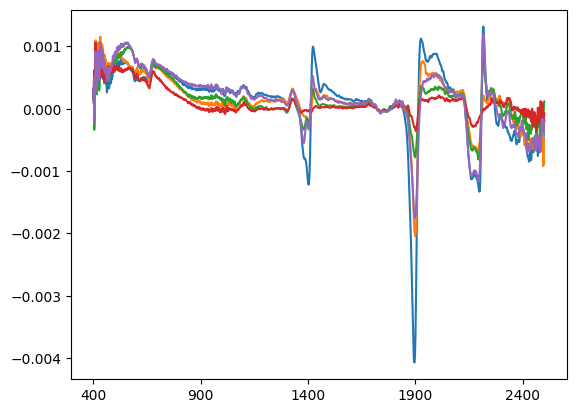

In [28]:
fod_spec = fod(smth_spec)

for i in range (0,5,1):
    fod_spec.iloc[i,:].plot()


## Continuum Removal

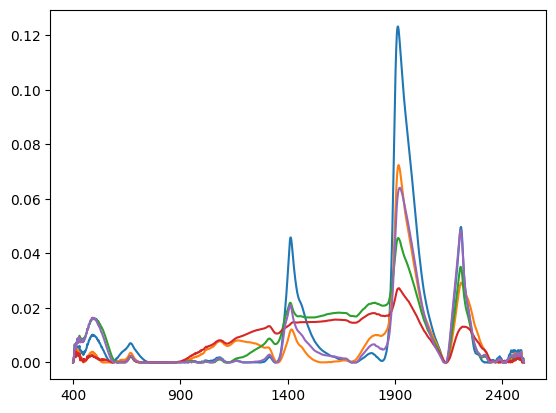

In [29]:
cr_spec = continuum_removed(spec2[51])

for i in range (0,5,1):
    cr_spec.iloc[i,:].plot()
    

## log(1/R) Transformation

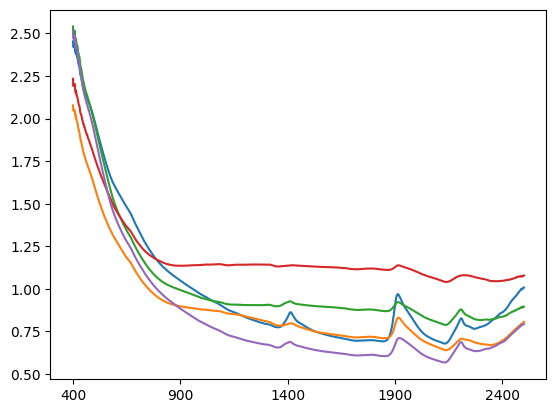

In [30]:
log_spec = ((1/spec2[51]).apply(np.log)).copy()
#log_spec.head(5)

for i in range (0,5,1):
    log_spec.iloc[i,:].plot()   

## Resampling (n_bands)

### 1. Sampled Original (sampled_spec)

In [31]:
sampled_spec = {}
for n in nbands_sampling:
    sampled_spec[n] = resample_spectra (spec2[51], n)

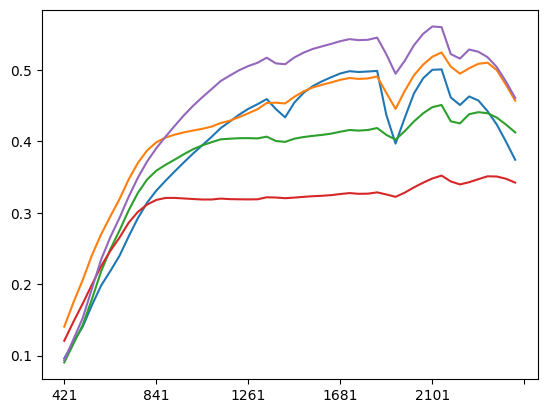

In [32]:
for i in range (0,5,1):
    sampled_spec[50].iloc[i,:].plot()

### 2. Sampled Continuum Removed  (sampled_cr)

In [33]:
sampled_cr = {}
for n in nbands_sampling:
    sampled_cr[n] = resample_spectra (cr_spec, n)

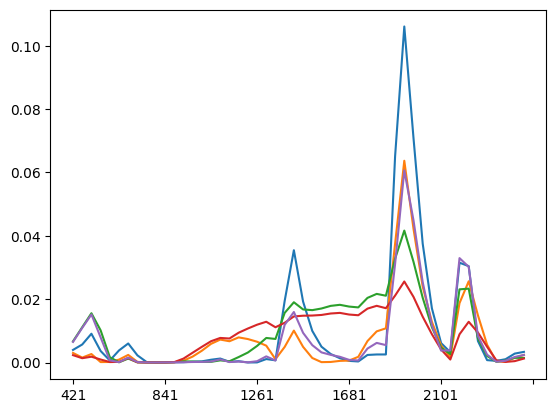

In [34]:
for i in range (0,5,1):
    sampled_cr[50].iloc[i,:].plot()

### 3. Sampled Log (sampled_log)

In [35]:
sampled_log = {}
for n in nbands_sampling:
    sampled_log[n] = resample_spectra (log_spec, n)

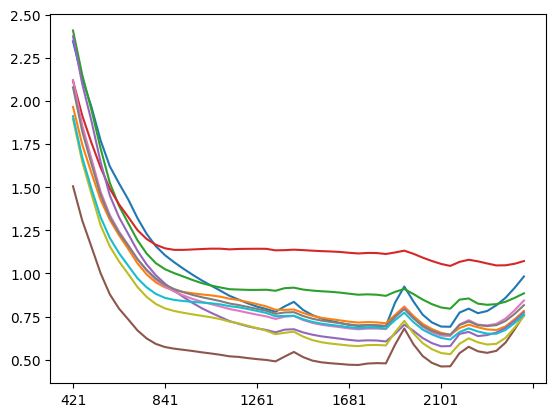

In [36]:
for i in range (0,10,1):
    sampled_log[50].iloc[i,:].plot()

### 4.  FOD of sampled spectra (fod_sampled)

In [37]:
fod_sampled = {}
for n in nbands_sampling:
    fod_sampled[n] = fod (sampled_spec[n])

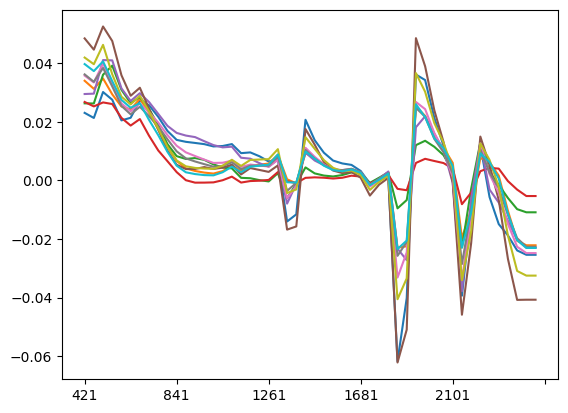

In [38]:
for i in range (0,10,1):
    fod_sampled[50].iloc[i,:].plot()

### 5. FOD of sampled_cr (fod_sampledcr)

In [39]:
fod_cr = {}
for n in nbands_sampling:
    fod_cr[n] = fod (sampled_cr[n])

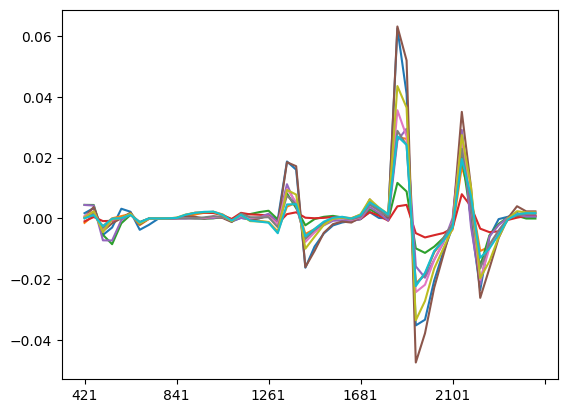

In [40]:
for i in range (0,10,1):
    fod_cr[50].iloc[i,:].plot()

### 6. FOD of sampled_log (fod_sampledlog)

In [41]:
fod_log = {}
for n in nbands_sampling:
    fod_log[n] = fod (sampled_log[n])

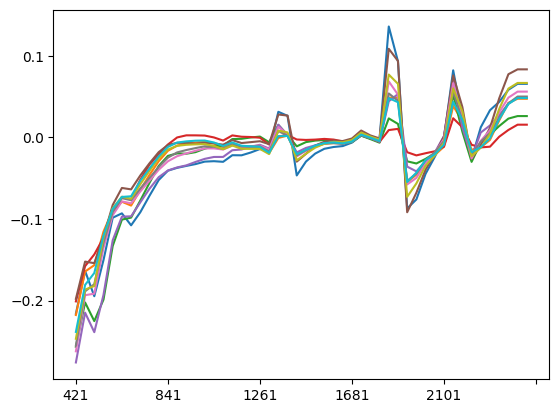

In [42]:
for i in range (0,10,1):
    fod_log[50].iloc[i,:].plot()

## Visualizing Processed Spectrum (variable samples)

In [43]:
(row, col) = spectra.shape
(row, col)

(795, 2101)

In [44]:
def plot_spec (sample, process):
    (row, col) = spectra.shape
    x1 = spec2[51].iloc[sample,:]
    x1.plot()
    if process == 'cr':
        x2 = cr_spec.iloc[sample,:]
        x2.plot()
    elif process == 'log':
        x3 = log_spec.iloc[sample,:]/3
        x3.plot()
    else:
        x4 = fod_spec.iloc[sample,:]*100
        x4.plot()
        
    plt.ylim([-0.6, 0.9])

ipywidgets.interact(plot_spec, sample = (0, row, 1), process = prepare_spec)

interactive(children=(IntSlider(value=397, description='sample', max=795), Dropdown(description='process', opt…

<function __main__.plot_spec(sample, process)>

## Correlation between wavelengths and Targets

In [45]:
def find_rpval (spectra, tar):
    (r, c) = spectra.shape
    
    r_val = spectra.iloc[[0], :].copy()
    p_val = spectra.iloc[[0], :].copy()
    
    for j in range(0, c):
        print("Length of tar:", len(tar))
        print("Length of spectra.iloc[:, j]:", len(spectra.iloc[:, j]))

        r_val.iloc[0,j], p_val.iloc[0,j] = stats.pearsonr(tar, spectra.iloc[:, j])
    
    return(r_val, p_val)


In [46]:
plt.style.use(['science','notebook','grid'])

def plot_corr (target, prepare, n_bands):
    
    i = target_names.index(target)    
    
    if  prepare == 'none':
        r_val, p_val = find_rpval (sampled_spec[n_bands], T[i])
        r_val.iloc[0,:].plot(color = clr[i])
    elif  prepare == 'cr':
        r_cr, p_cr = find_rpval (sampled_cr[n_bands], T[i])
        r_cr.iloc[0,:].plot(color = clr[i])
    elif prepare == 'log':
        r_log, p_log = find_rpval (sampled_log[n_bands], T[i])
        r_log.iloc[0,:].plot(color = clr[i])
    elif prepare == 'fod_spec':    
        r_fod, p_fod = find_rpval (fod_sampled[n_bands], T[i])
        r_fod.iloc[0,:].plot(color = clr[i]) 
    elif prepare == 'fod_cr':    
        r_sfodcr, p_sfodcr = find_rpval (fod_cr[n_bands], T[i])
        r_sfodcr.iloc[0,:].plot(color = clr[i]) 
    else:   
        r_sfodlog, p_sfodlog = find_rpval (fod_log[n_bands], T[i])
        r_sfodlog.iloc[0,:].plot(color = clr[i]) 
    
    plt.ylim([-0.9, 0.9])


ipywidgets.interact(plot_corr, target = target_names, prepare = prepare_spec, n_bands = nbands_sampling)



interactive(children=(Dropdown(description='target', options=('TOC',), value='TOC'), Dropdown(description='pre…

<function __main__.plot_corr(target, prepare, n_bands)>

In [47]:
Data = {'spectra' : spec2[51], 'T' : T, 'spec1': spec1, 'spec2': spec2, 'smth_spec' : smth_spec, 'fod_spec' : fod_spec,  \
       'cr_spec' : cr_spec,  'log_spec' : log_spec, 'sampled_spec' : sampled_spec, 'sampled_cr' : sampled_cr, \
        'fod_sampled' : fod_sampled, 'sampled_log' : sampled_log, 'fod_cr' : fod_cr, 'fod_log' : fod_log}

In [48]:
with open ('data.pickle', 'wb') as file:
    pickle.dump(Data, file)